# spatial neighbourhoods

In [2]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.neighbors import radius_neighbors_graph
import scanpy as sc

def spatial_neighbourhoods_fast(
    ad,
    cluster_label="leiden_0.5",
    max_distance=200.0,
    x_col="x_centroid",
    y_col="y_centroid",
):
    """
    Returns an AnnData where X is (cells x clusters) with counts of neighbors
    within `max_distance` per cluster. Uses sparse ops (fast + memory-light).
    """
    # --- coordinates ---
    coords = ad.obs[[x_col, y_col]].to_numpy()

    # Sparse adjacency (N x N) with 1 if within radius, excluding self
    A = radius_neighbors_graph(
        coords, radius=max_distance, mode="connectivity",
        include_self=False, n_jobs=-1
    ).tocsr()

    # --- cluster one-hot (N x K) ---
    cats = ad.obs[cluster_label].astype("category")
    cat_codes = cats.cat.codes.to_numpy()
    N = ad.n_obs
    K = len(cats.cat.categories)
    rows = np.arange(N, dtype=int)
    C = sp.csr_matrix((np.ones(N, dtype=np.int32), (rows, cat_codes)), shape=(N, K))

    # --- neighbor counts per cluster: F = A @ C  (N x K) ---
    F = A @ C  # integer counts

    # Build output AnnData
    out = sc.AnnData(
        X=F,
        obs=ad.obs.copy(),
        var=pd.DataFrame(index=[str(c) for c in cats.cat.categories])
    )
    # Keep the adjacency if you want it later (in obsp, not layers)
    out.obsp["neighbors_within_radius"] = A
    out.uns["spatial_neighbourhoods"] = {
        "cluster_label": cluster_label,
        "max_distance": float(max_distance),
        "x_col": x_col,
        "y_col": y_col,
    }
    return out



In [3]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation.h5ad')

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# run spatial neigbourshoods

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


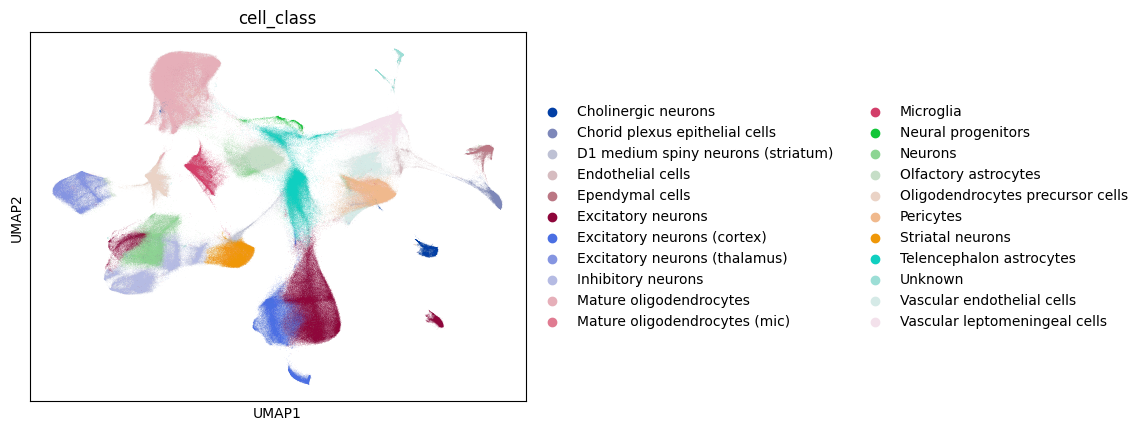

In [4]:
sc.pl.umap(adata, color = 'cell_class')

In [5]:
adata.obs.sample_id.unique()

['RB4282', 'RB4350', 'RB4401', 'RB4403', 'RB4405', ..., 'RB4627', 'RB4630', 'RB4653', 'RB4658', 'RB4676']
Length: 12
Categories (12, object): ['RB4282', 'RB4350', 'RB4401', 'RB4403', ..., 'RB4630', 'RB4653', 'RB4658', 'RB4676']

In [54]:
%%time
sample_ids = ["RB4405"]  # or: adata.obs["sample_id"].unique().tolist()
ad_sn_list = [
    spatial_neighbourhoods_fast(
        adata[adata.obs["sample_id"] == sid],
        cluster_label="cell_class",
        max_distance=100,
        x_col="x_centroid",
        y_col="y_centroid",
    )
    for sid in sample_ids
]

CPU times: user 1.35 s, sys: 22.7 ms, total: 1.38 s
Wall time: 259 ms


In [55]:
ad_sn_list

[AnnData object with n_obs × n_vars = 74839 × 22
     obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type'
     uns: 'spatial_neighbourhoods'
     obsp: 'neighbors_within_radius']

In [56]:
%%time
ad_sn = sc.concat(ad_sn_list, join = 'outer', fill_value = 0)

CPU times: user 18.5 ms, sys: 3.88 ms, total: 22.4 ms
Wall time: 27.1 ms


In [57]:
%%time
spatial = np.array(ad_sn.obs[['x_centroid','y_centroid']])
ad_sn.obsm['spatial'] = spatial

CPU times: user 1.95 ms, sys: 404 µs, total: 2.35 ms
Wall time: 2.05 ms


In [58]:
%%time
sc.pp.neighbors(ad_sn, n_neighbors=10)
sc.tl.umap(ad_sn,min_dist=0.2)

CPU times: user 11min 32s, sys: 10.8 s, total: 11min 43s
Wall time: 58.8 s


/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


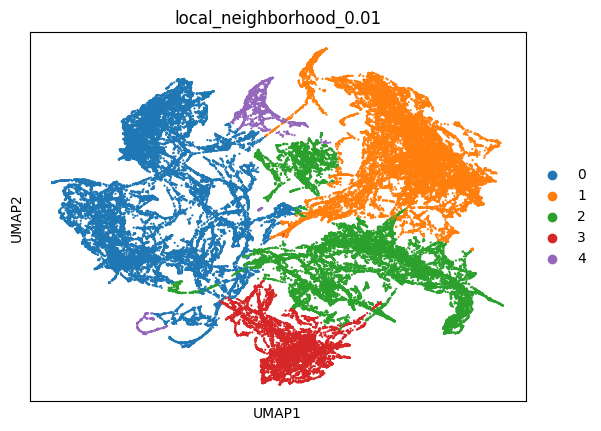

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


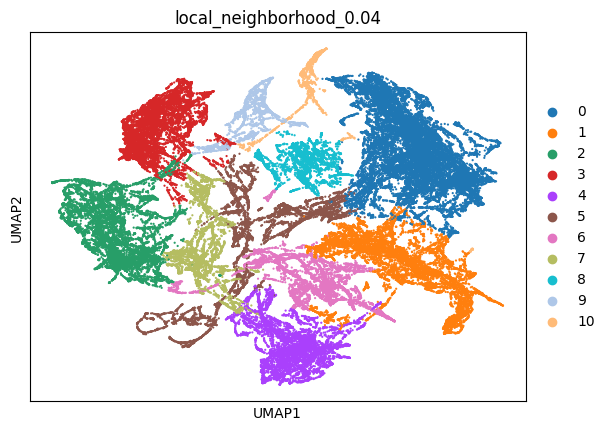

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


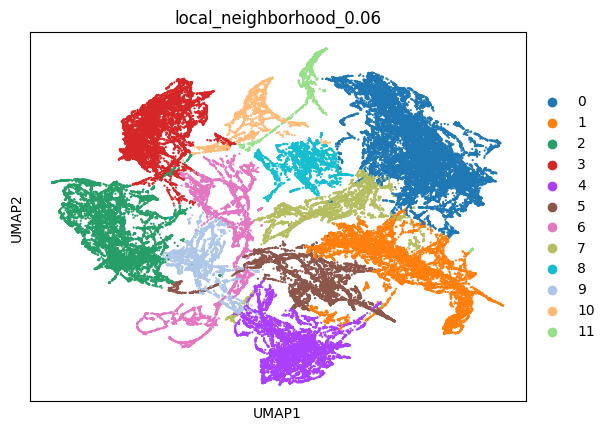

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


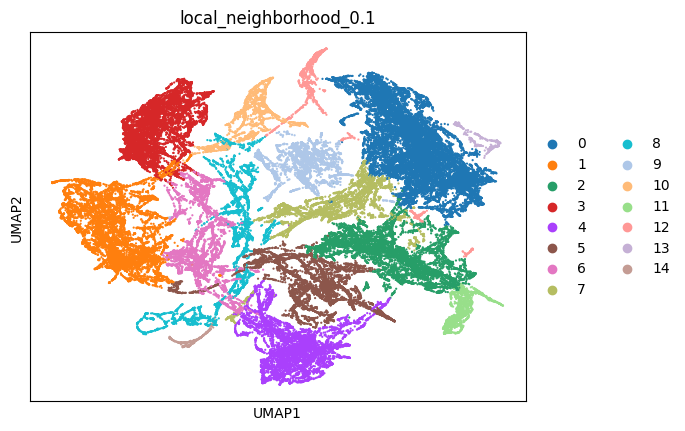

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


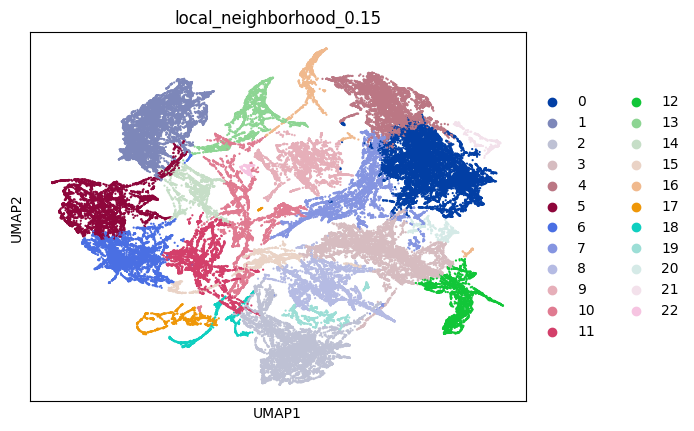

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


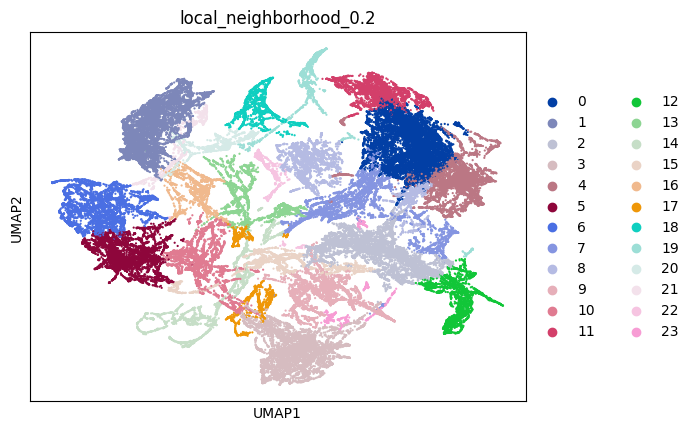

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


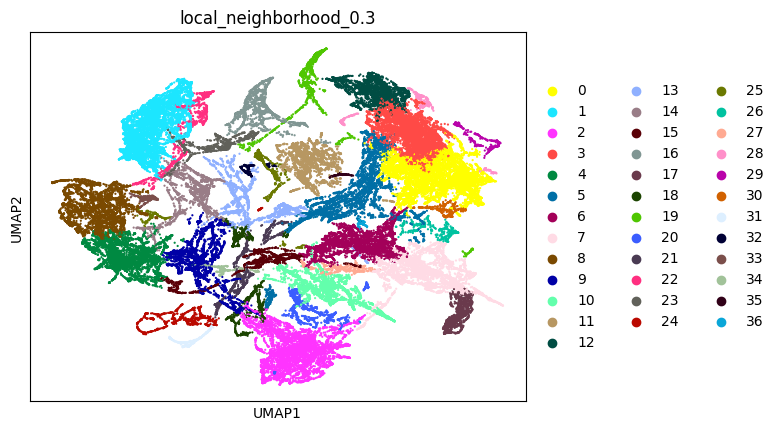

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


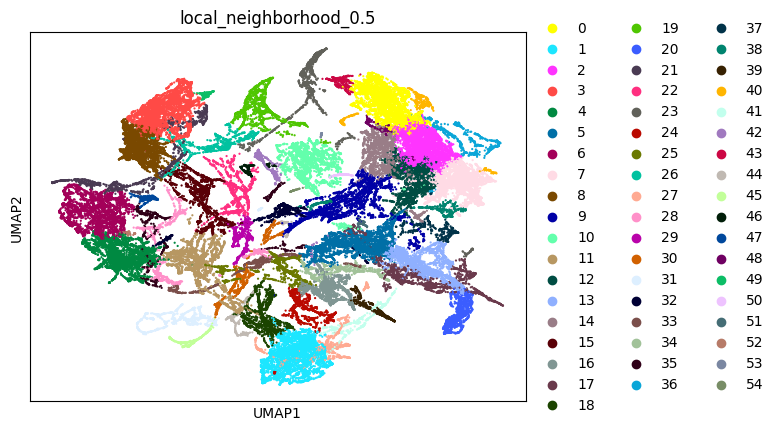

CPU times: user 7.18 s, sys: 122 ms, total: 7.3 s
Wall time: 7.29 s


In [88]:
%%time
for i in [0.01,  0.04, 0.06,0.1,0.15,0.2,0.3,0.5]: 
    key = 'local_neighborhood_'+str(i)
    if key in ad_sn.obs.columns: 
        sc.pl.umap(ad_sn,color=[key],  s = 10)#,save='UMAP_10X_colors.svg')
    else: 
        sc.tl.leiden(ad_sn,resolution=i, key_added = key)
        sc.pl.umap(ad_sn,color=[key],  s = 10)#,save='UMAP_10X_colors.svg')

In [60]:
import matplotlib.pyplot as plt

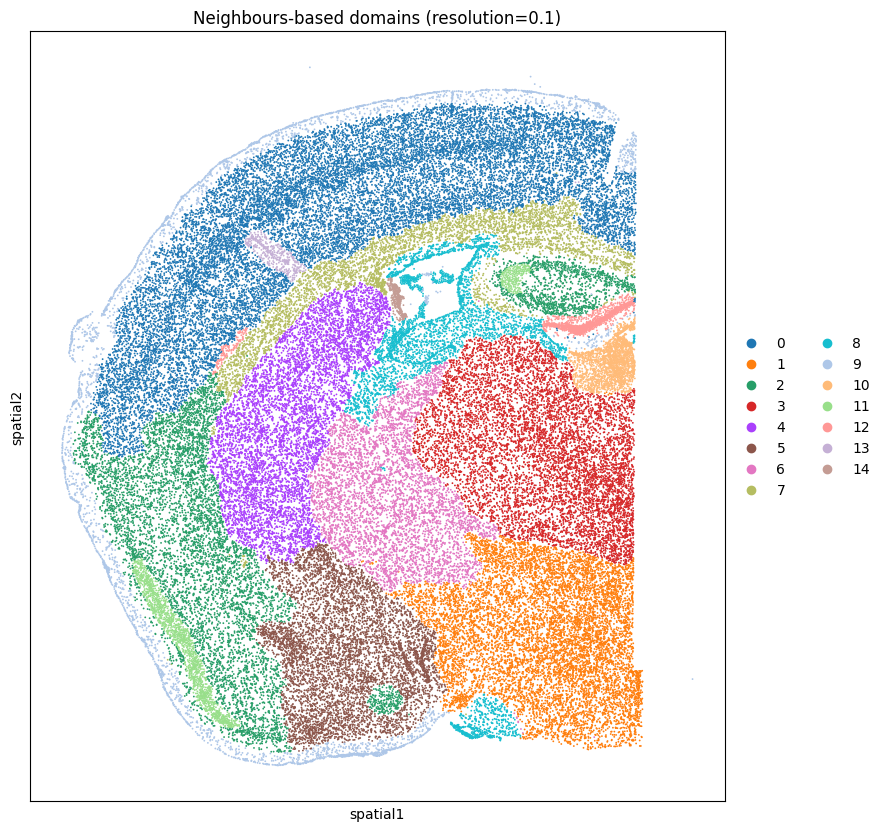

In [91]:
# 5) Plot a spatial map for your favorite resolution:
with plt.rc_context({"figure.figsize": (10, 10)}):
    sc.pl.spatial(
        ad_sn,
        color='local_neighborhood_0.1',
        spot_size=15,
        title="Neighbours-based domains (resolution=0.1)"
    )

In [92]:
import scanpy as sc
import pandas as pd
import scipy
import matplotlib.pyplot as plt

def post_merge(df, labels, post_merge_cutoff, linkage_method='single', 
               linkage_metric='correlation', fcluster_criterion='distance', name='', save=False):
    Z = scipy.cluster.hierarchy.linkage(df.T, method=linkage_method, metric=linkage_metric)
    merged_labels_short = scipy.cluster.hierarchy.fcluster(Z, post_merge_cutoff, criterion=fcluster_criterion)

    # map cluster name to merged label
    label_conversion = dict(zip(df.columns, merged_labels_short))
    new_labels = [label_conversion[i] for i in labels]

    # Plot
    fig, ax = plt.subplots(figsize=(20, 10))
    scipy.cluster.hierarchy.dendrogram(Z, labels=df.columns, color_threshold=post_merge_cutoff, ax=ax)
    ax.hlines(post_merge_cutoff, 0, ax.get_xlim()[1])
    ax.set_title('Merged clusters')
    ax.set_ylabel(linkage_metric, fontsize=20)
    ax.set_xlabel('Pre-merge cluster labels', fontsize=20)
    ax.tick_params(axis="x", labelrotation=90, labelsize=10)  # <-- rotate tick labels
    plt.show()
    if save:
        fig.savefig(f"{name}.svg", dpi=500)
    
    return new_labels

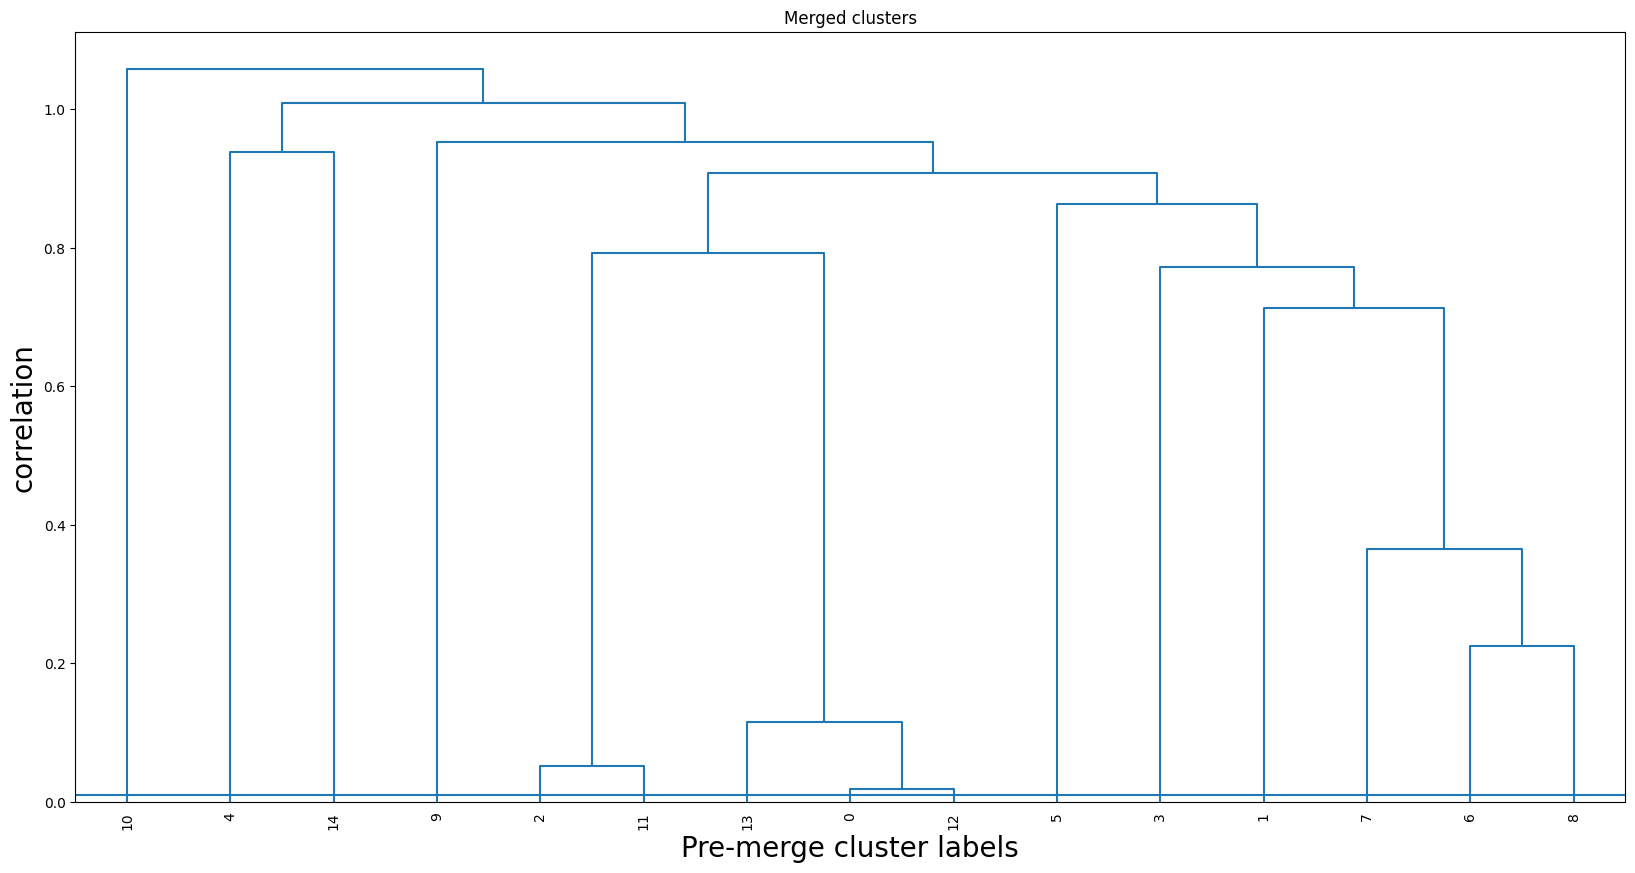

In [95]:
# Compute cluster-level mean expression
cluster_key = 'local_neighborhood_0.1'
expr = pd.DataFrame(ad_sn.X, index=ad_sn.obs_names, columns=ad_sn.var_names)
cluster_means = expr.groupby(ad_sn.obs[cluster_key]).mean().T  # genes x clusters

# Run post-merge
merged_labels = post_merge(cluster_means, labels=ad_sn.obs[cluster_key].tolist(),
                           post_merge_cutoff=0.01,
                           linkage_metric='correlation',
                           linkage_method='average',
                           name='SupFig3Dend',
                           save=False)

# Add new merged label to AnnData object
ad_sn.obs['merged_cluster'] = merged_labels
ad_sn.obs['merged_cluster'] = ad_sn.obs['merged_cluster'].astype(str)

RB4405


/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


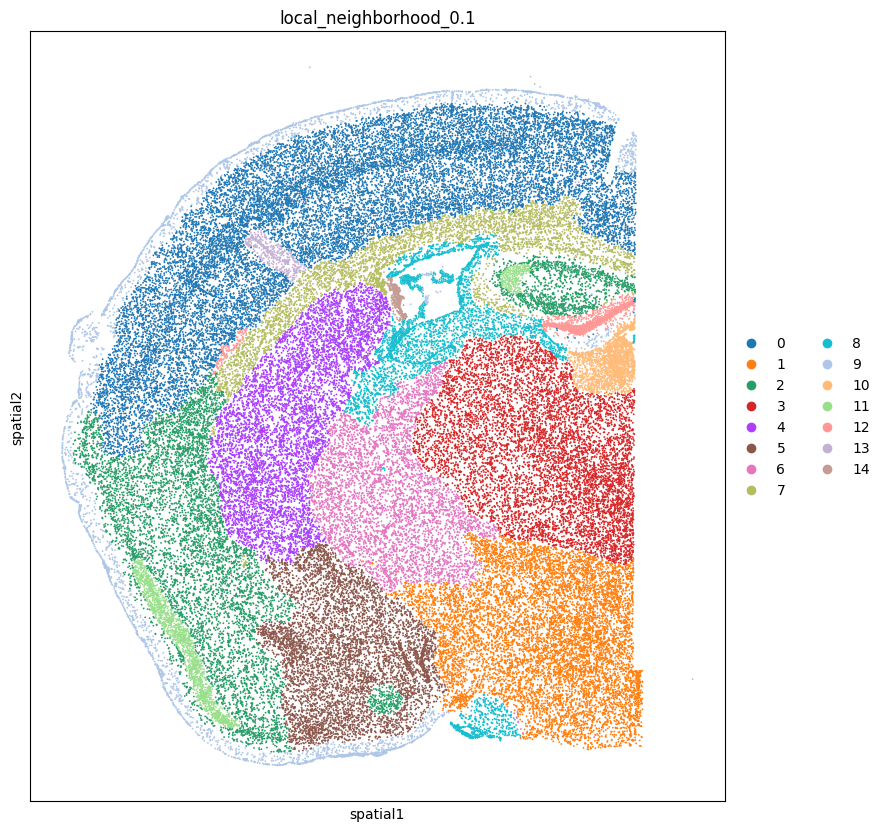

In [96]:
for run in ad_sn.obs['sample_id'].unique():
    print(run)
    ad_int = ad_sn[ad_sn.obs['sample_id'] == run]

    with plt.rc_context({'figure.figsize': (20, 10)}):
        sc.pl.spatial(ad_int, spot_size=15, color = 'local_neighborhood_0.1')
    plt.show()
    

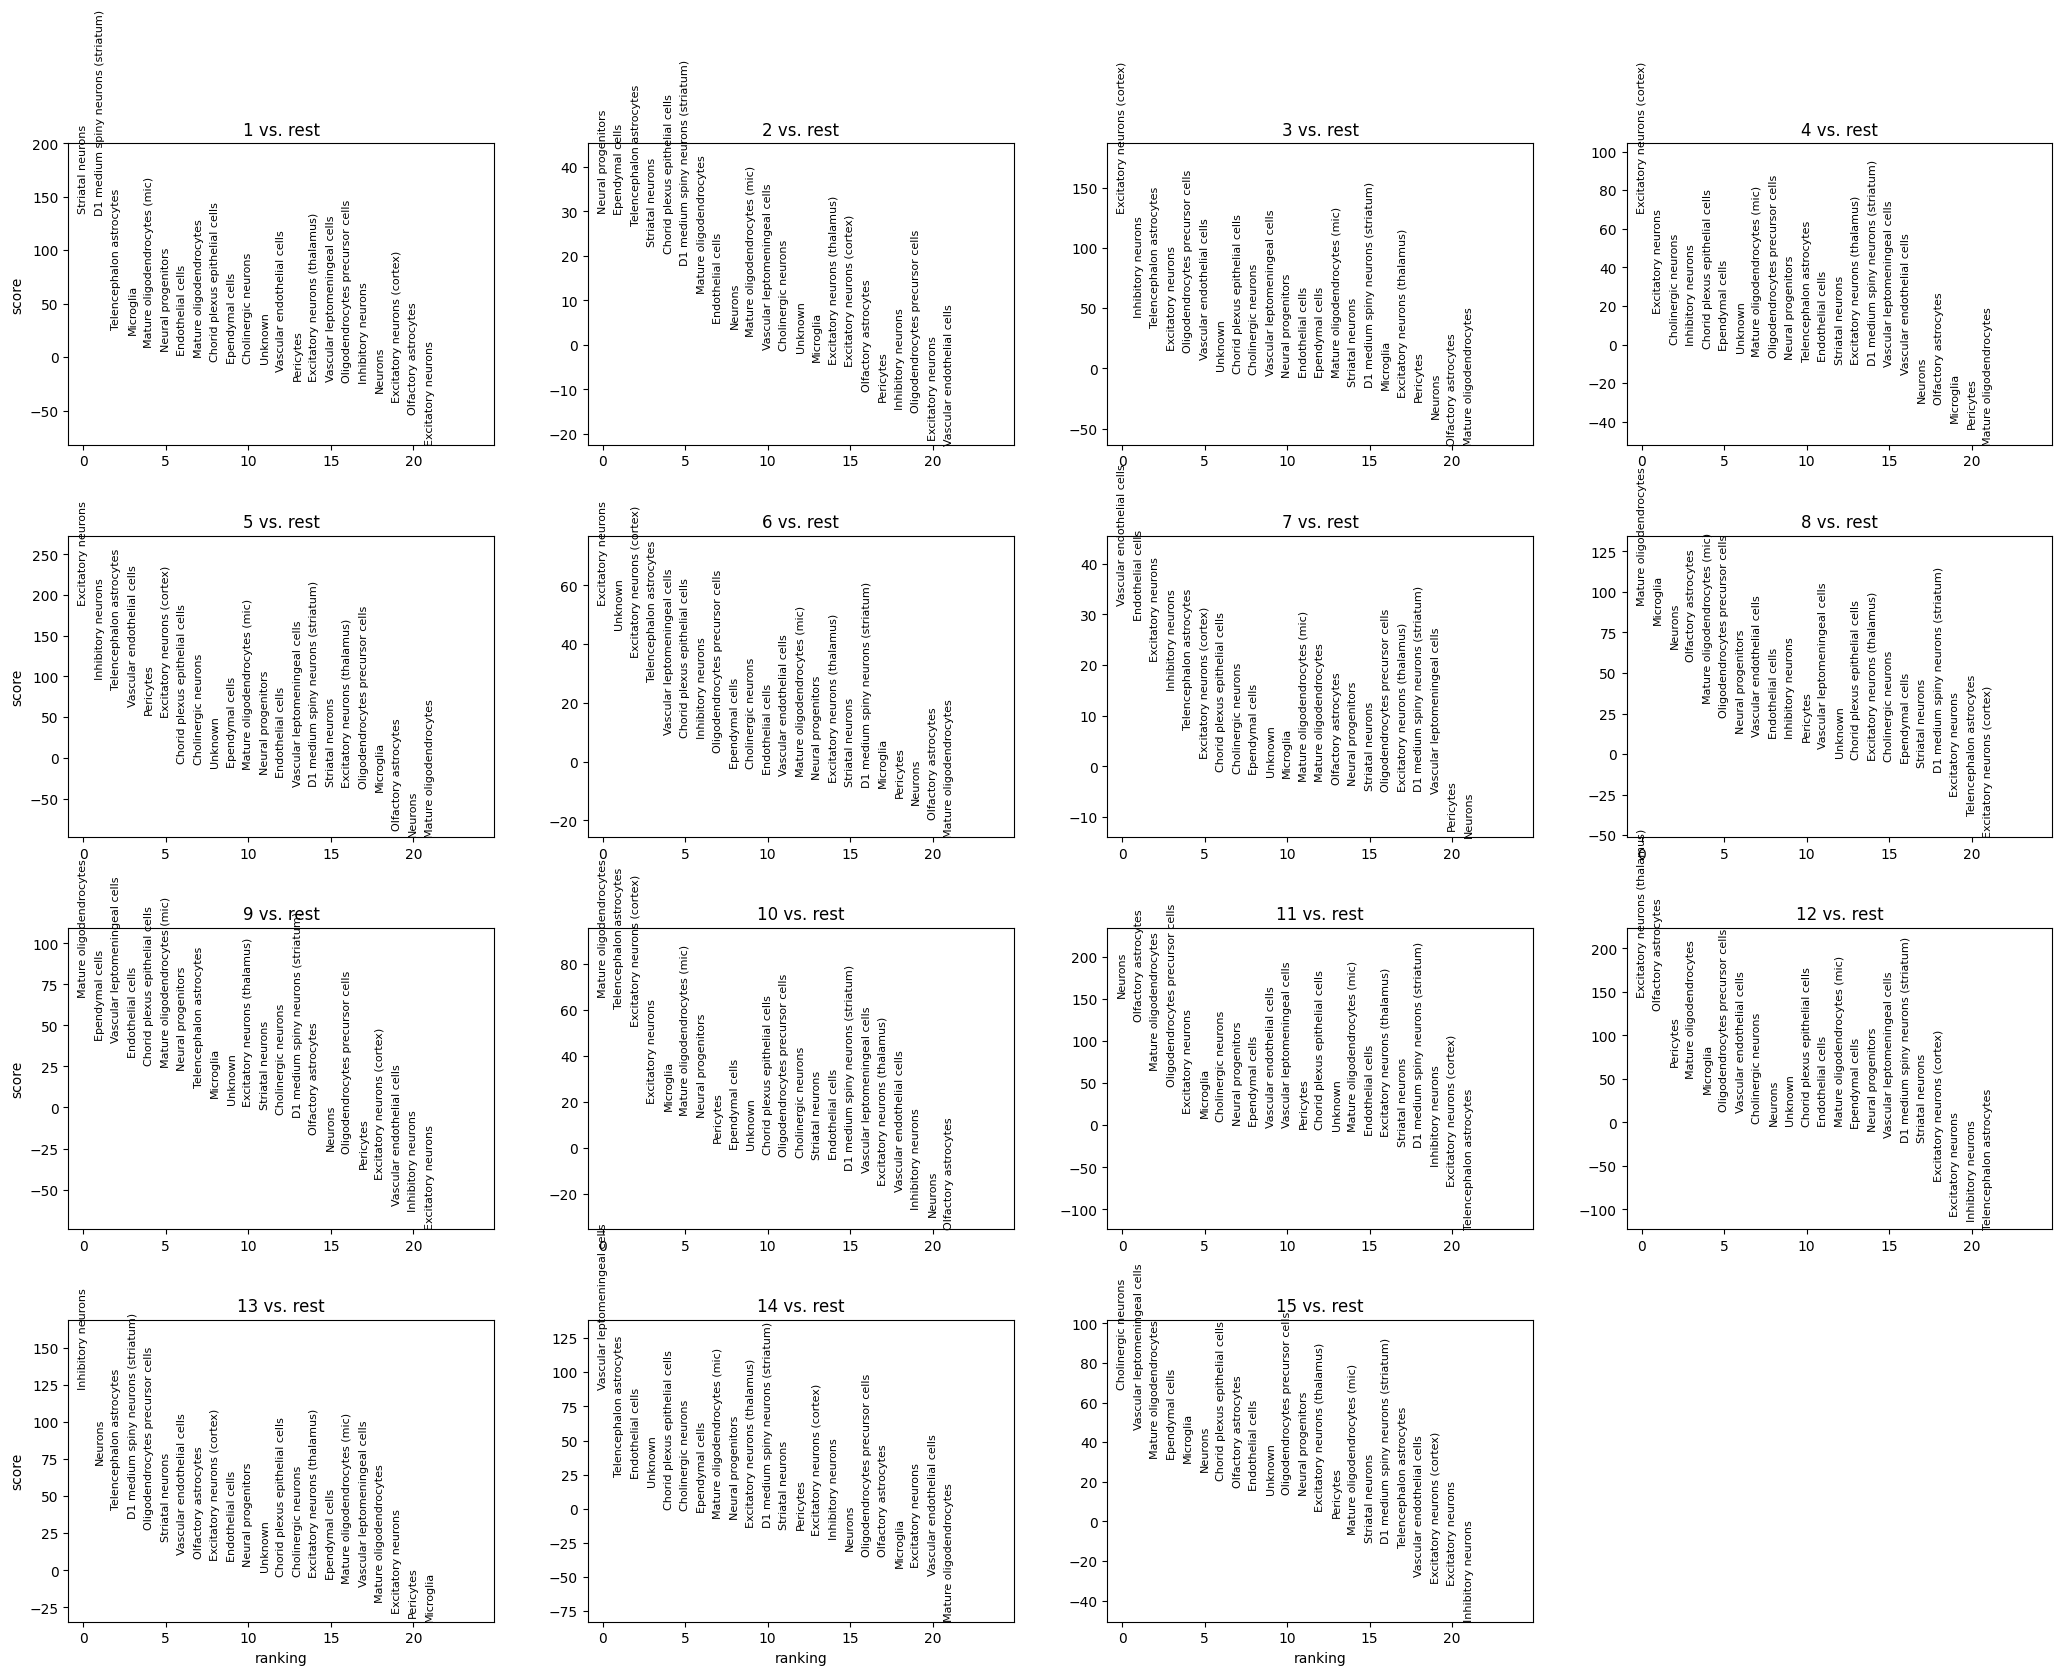

1
Striatal neurons D1 medium spiny neurons (striatum) Telencephalon astrocytes Microglia Mature oligodendrocytes (mic) Neural progenitors Endothelial cells Mature oligodendrocytes Chorid plexus epithelial cells Ependymal cells
 
2
Neural progenitors Ependymal cells Telencephalon astrocytes Striatal neurons Chorid plexus epithelial cells D1 medium spiny neurons (striatum) Mature oligodendrocytes Endothelial cells Neurons Mature oligodendrocytes (mic)
 
3
Excitatory neurons (cortex) Inhibitory neurons Telencephalon astrocytes Excitatory neurons Oligodendrocytes precursor cells Vascular endothelial cells Unknown Chorid plexus epithelial cells Cholinergic neurons Vascular leptomeningeal cells
 
4
Excitatory neurons (cortex) Excitatory neurons Cholinergic neurons Inhibitory neurons Chorid plexus epithelial cells Ependymal cells Unknown Mature oligodendrocytes (mic) Oligodendrocytes precursor cells Neural progenitors
 
5
Excitatory neurons Inhibitory neurons Telencephalon astrocytes Vascular

In [99]:
sc.tl.rank_genes_groups(ad_sn, groupby='merged_cluster', method='wilcoxon')
# See top 5 marker genes per cluster
sc.pl.rank_genes_groups(ad_sn, n_genes=25, sharey=False)

marker_genes = pd.DataFrame({
    group: ad_sn.uns['rank_genes_groups']['names'][group][:10]
    for group in ad_sn.uns['rank_genes_groups']['names'].dtype.names
})
marker_genes.head()
#marker_genes.to_csv('../data/broad_markers_leiden0-5.csv')
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')

In [101]:
dict(zip(ad_sn.obs["local_neighborhood_0.1"].cat.categories, ad_sn.obs["local_neighborhood_0.1"].cat.categories))

{'0': '0',
 '1': '1',
 '2': '2',
 '3': '3',
 '4': '4',
 '5': '5',
 '6': '6',
 '7': '7',
 '8': '8',
 '9': '9',
 '10': '10',
 '11': '11',
 '12': '12',
 '13': '13',
 '14': '14'}

In [106]:
anno = {'0': 'Isocortex',
 '1': 'Hypothalamus',
 '2': 'Olfactory areas',
 '3': 'Thalamus',
 '4': 'Striatum',
 '5': 'Striatum-like amygdalar nculei',
 '6': 'Palladium',
 '7': 'Corpus callosum',
 '8': 'Fornix system',
 '9': 'Meninges',
 '10': 'Medial habenula',
 '11': 'Piriform area',
 '12': 'Isocortex',
 '13': 'Isocortex',
 '14': 'Fornix system'}

In [107]:
ad_sn.obs['compartment'] = ad_sn.obs["local_neighborhood_0.1"].map(anno)

RB4405


/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


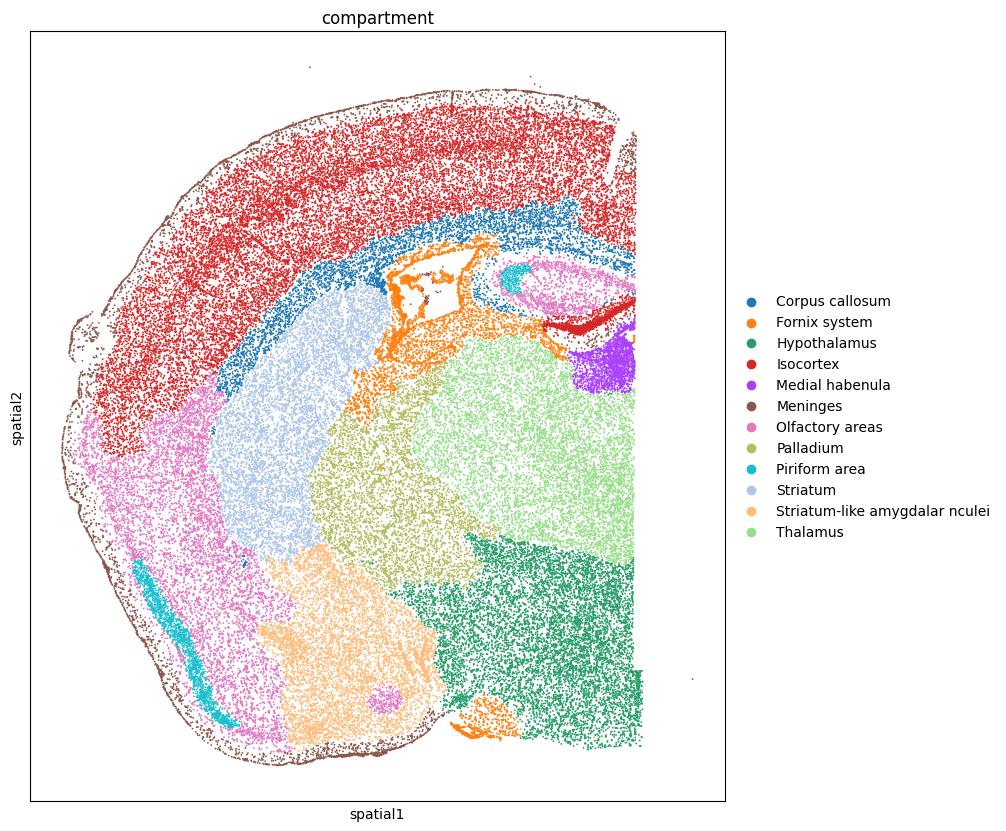

In [109]:
for run in ad_sn.obs['sample_id'].unique():
    print(run)
    ad_int = ad_sn[ad_sn.obs['sample_id'] == run]

    with plt.rc_context({'figure.figsize': (20, 10)}):
        sc.pl.spatial(ad_int, spot_size=15, color = 'compartment')
    plt.show()
    

In [115]:
ad_sub = adata[adata.obs["sample_id"] == 'RB4405']

In [116]:
ad_sub.obs['compartment'] = ad_sub.obs.index.map(dict(zip(ad_sn.obs.index,ad_sn.obs.compartment)))

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_7032/1728593424.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad_sub.obs['compartment'] = ad_sub.obs.index.map(dict(zip(ad_sn.obs.index,ad_sn.obs.compartment)))


In [117]:
ad_sub.obs['compartment']

cell_id
aaaajgpb-1                          Meninges
aaabecke-1                         Isocortex
aaacplch-1                         Isocortex
aaadedfd-1                          Meninges
aaadjcin-1                         Isocortex
                           ...              
ojbiaddp-1    Striatum-like amygdalar nculei
ojbijncf-1    Striatum-like amygdalar nculei
ojbincoj-1    Striatum-like amygdalar nculei
ojbjcmcm-1    Striatum-like amygdalar nculei
ojbjfclo-1    Striatum-like amygdalar nculei
Name: compartment, Length: 74839, dtype: object

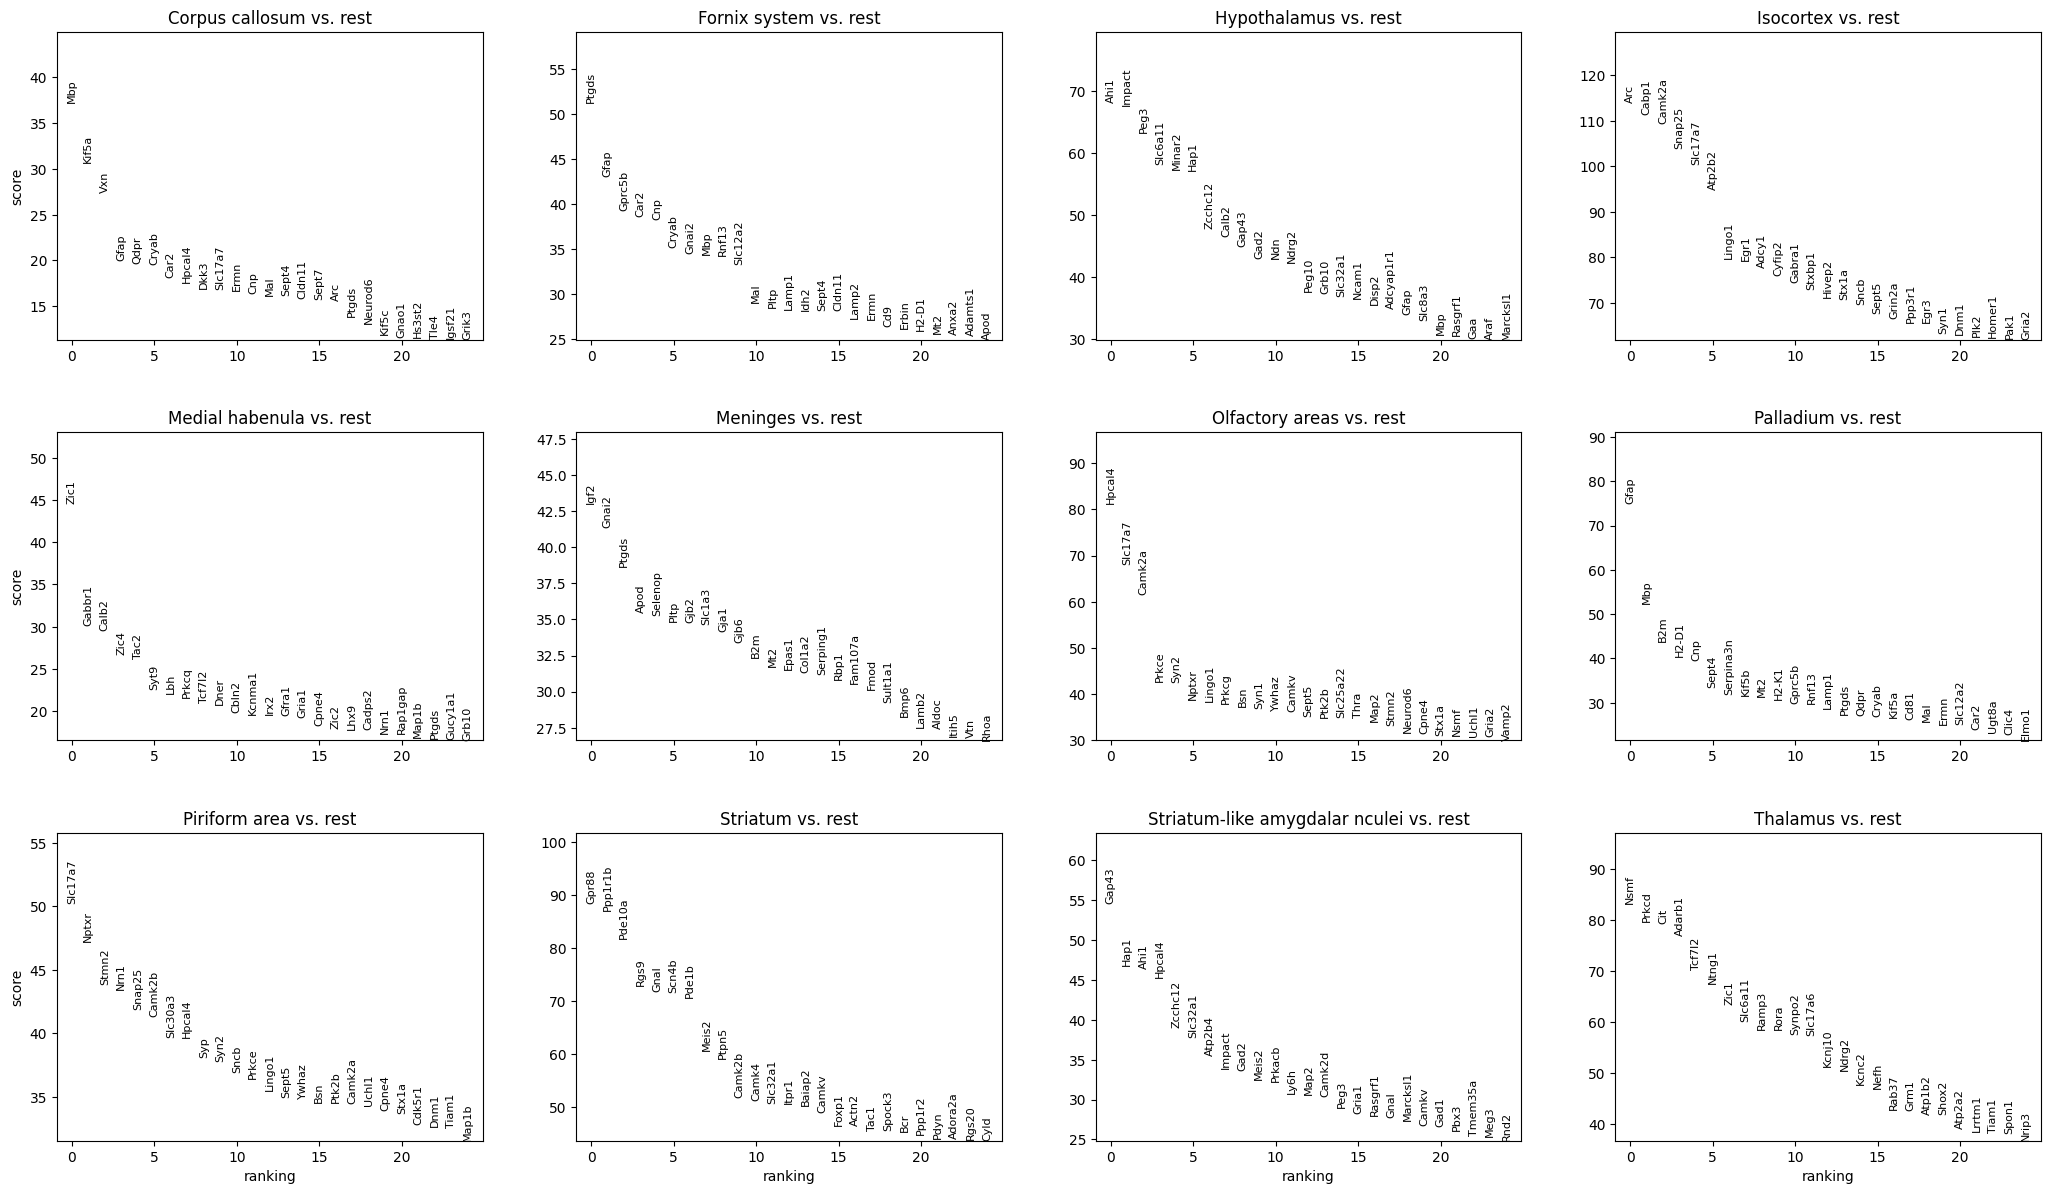

Corpus callosum
Mbp Kif5a Vxn Gfap Qdpr Cryab Car2 Hpcal4 Dkk3 Slc17a7
 
Fornix system
Ptgds Gfap Gprc5b Car2 Cnp Cryab Gnai2 Mbp Rnf13 Slc12a2
 
Hypothalamus
Ahi1 Impact Peg3 Slc6a11 Minar2 Hap1 Zcchc12 Calb2 Gap43 Gad2
 
Isocortex
Arc Cabp1 Camk2a Snap25 Slc17a7 Atp2b2 Lingo1 Egr1 Adcy1 Cyfip2
 
Medial habenula
Zic1 Gabbr1 Calb2 Zic4 Tac2 Syt9 Lbh Prkcq Tcf7l2 Dner
 
Meninges
Igf2 Gnai2 Ptgds Apod Selenop Pltp Gjb2 Slc1a3 Gja1 Gjb6
 
Olfactory areas
Hpcal4 Slc17a7 Camk2a Prkce Syn2 Nptxr Lingo1 Prkcg Bsn Syn1
 
Palladium
Gfap Mbp B2m H2-D1 Cnp Sept4 Serpina3n Kif5b Mt2 H2-K1
 
Piriform area
Slc17a7 Nptxr Stmn2 Nrn1 Snap25 Camk2b Slc30a3 Hpcal4 Syp Syn2
 
Striatum
Gpr88 Ppp1r1b Pde10a Rgs9 Gnal Scn4b Pde1b Meis2 Ptpn5 Camk2b
 
Striatum-like amygdalar nculei
Gap43 Hap1 Ahi1 Hpcal4 Zcchc12 Slc32a1 Atp2b4 Impact Gad2 Meis2
 
Thalamus
Nsmf Prkcd Cit Adarb1 Tcf7l2 Ntng1 Zic1 Slc6a11 Ramp3 Rora
 


In [118]:
sc.tl.rank_genes_groups(ad_sub, groupby='compartment', method='wilcoxon')
# See top 5 marker genes per cluster
sc.pl.rank_genes_groups(ad_sub, n_genes=25, sharey=False)

marker_genes = pd.DataFrame({
    group: ad_sub.uns['rank_genes_groups']['names'][group][:10]
    for group in ad_sub.uns['rank_genes_groups']['names'].dtype.names
})
marker_genes.head()
#marker_genes.to_csv('../data/broad_markers_leiden0-5.csv')
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')

In [122]:
mtDSB_genes = [
    "Hspa5", "Hspa9", "Hsph1",
    "Atf5", "Trib3", "Zbtb16", "Ddit3",
    "Cdkn1a", "Bcl2l1",
    "Sgk1", "Nmu", "Plin4", "Aldoa",
    "Serpina3n", "Mt2", "Gstp1",'Ldha'
]

/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


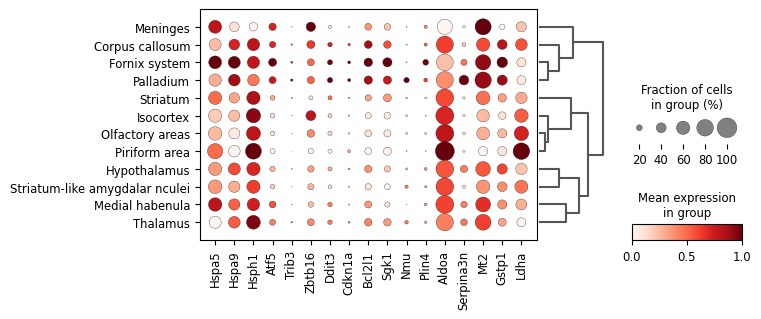

In [127]:
sc.pl.dotplot(
        ad_sub,
        var_names=mtDSB_genes,
        groupby="compartment",
        standard_scale="var",
        #dot_max=0.5,
        #dot_min=0.05,
        color_map="Reds",
        
        dendrogram=True,
        figsize=(7, 3)
    )